Atividade 5: Realizar uma pré-distorção
a. Partindo dos resultados da Atividade 3, o PA a ser linearizado é um modelo MP (ou seja, seu PA será o modelo MP treinado na Atividade 3). 
b. Treinar um DPD. Como modelo de DPD, usar o MP (ou seja, PA e DPD terão a mesma equação, porém coeficientes diferentes). Para treinar o DPD, primeiro coletar dados na entrada e na saída do MP que modelo o PA (ou seja, passar o in_extraction no MP e medir a saída estimada). No DPD, trocam-se os papeís de entrada e saída (ou seja, saída do PA é entrada do DPD e vice-versa)
c. Obter a seguinte cascata (modelo MP do DPD +  modelo MP do PA):
c1. O sinal de entrada, a ser aplicado no modelo MP do DPD  treinado no item b. é ganho*in_validation. O ganho é um número fixo e evita extrapolação do modelo. Obtê-lo usando ganho= abs(out_esimado_PA)/abs(in).  
c2. O sinal estimado na saída do modelo MP do DPD  agora deve ser aplicado como entrada do modelo MP do PA. 
d. Para validar a pré-distorção, comparar a entrada da cascata com a saída da cascata.


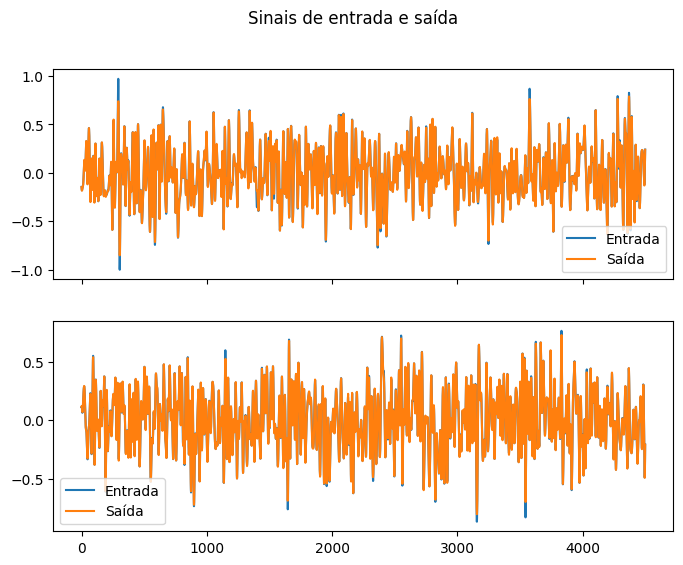

In [1]:
from functions import *


INPUT_DIT = os.path.join('..', 'INPUT')
OUTPUT_DIR = os.path.join('..', 'OUTPUT')
VHDL_DIR = os.path.join('..', 'VHDL')

file_in_output = lambda file : os.path.join(OUTPUT_DIR, file)
file_in_input = lambda file : os.path.join(INPUT_DIT, file)
file_in_VHDL = lambda file : os.path.join(VHDL_DIR, file)
file_name = 'in_out_SBRT2_direto'
file_name = 'data_LDMOS_formatted_4500p'
csv_file_name = file_name + "_validation.csv"

mat = loadmat(file_in_input(file_name + '.mat'))

in_data_ext = mat['in_extraction']
out_data_ext = mat['out_extraction']
in_data_val = mat['in_validation']
out_data_val = mat['out_validation']


import numpy as np

# Agrupa todos os dados em um único array
dados_concatenados = np.concatenate([in_data_ext, out_data_ext, in_data_val, out_data_val])

# Calcula o máximo entre o valor absoluto da parte real e imaginária de todos os elementos
maior_modulo = np.maximum(np.abs(dados_concatenados.real), np.abs(dados_concatenados.imag)).max()


in_ext_norm  = in_data_ext / maior_modulo
out_ext_norm = out_data_ext / maior_modulo
in_val_norm  = in_data_val / maior_modulo
out_val_norm = out_data_val / maior_modulo

plot_signals(in_ext_norm,out_ext_norm, in_val_norm,out_val_norm)

In [2]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model(x_in, coef, ordem, memoria):
    """
    Modelo Memory Polynomial estruturado por blocos

    coef : vetor complexo organizado como:
           [b_{1,0}, ..., b_{P,0},
            b_{1,1}, ..., b_{P,1},
            ...
            b_{1,M}, ..., b_{P,M}]
    """
    x_in = x_in.flatten()
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex).flatten()

    idx = 0
    for m in range(memoria + 1):
        # Atraso
        x_delay = np.roll(x_in, m)

        # Coeficientes desse bloco de memória
        coef_m = coef[idx:idx + ordem]
        idx += ordem

        # Bloco do somatório (figura que você mostrou)
        y_est += bloco_memoria_mp(x_delay, coef_m, ordem)

    return y_est

def erro_mp_complex_blocos(params, x_in, y_out, ordem, memoria):
    """
    Erro do modelo MP estruturado por blocos
    """
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model(x_in, coef, ordem, memoria)
    erro = y_out - y_est

    return np.abs(erro) 


In [3]:
M = 2
P = 5
from scipy.optimize import least_squares


def extract_coefficients(in_ext,out_ext,M, P, bounds = (-np.inf, np.inf)):
    in_ext = in_ext.flatten()
    out_ext = out_ext.flatten()
    num_coef = P * (M + 1)
    x0 = np.zeros(2*num_coef)
    
    res = least_squares(
    erro_mp_complex_blocos,
    x0,
    bounds=bounds,
    args=(in_ext, out_ext, P, M),
    verbose=2
    )

    coefficients = res.x[:num_coef] + 1j*res.x[num_coef:]
    print("Coeficientes complexos otimizados:", coefficients)
    
    return coefficients   

if "coefficients_pa_float.npy" in os.listdir(OUTPUT_DIR):
    coefficients_PA_float = np.load(os.path.join(OUTPUT_DIR, "coefficients_pa_float.npy"))
else:
    # calculo dos coeficientes do modelo do PA
    coefficients_PA_float = extract_coefficients(in_data_ext,out_data_ext,M, P)
    np.save(file_in_output("coefficients_pa_float.npy"), coefficients_PA_float)
# Saida estimada do modelo do PA
predicted_ext_PA = mp_model(in_data_ext, coefficients_PA_float, P, M)


# Calculo do modelo do pre-distorcedor
if "coefficients_dpd_float.npy" in os.listdir(OUTPUT_DIR):
    coefficients_DPD_float = np.load(file_in_output("coefficients_dpd_float.npy"))
else:   
    coefficients_DPD_float = extract_coefficients(predicted_ext_PA,in_data_ext, M, P)
    np.save(file_in_output("coefficients_dpd_float.npy"), coefficients_DPD_float)
# Saida estimada do modelo do predistorcedor
predicted_ext_pre = mp_model(predicted_ext_PA.flatten(), coefficients_DPD_float, P, M)





In [4]:
# saida estimada da cascata

import numpy as np


predicted_val_PA = mp_model(in_data_val, coefficients_PA_float, P, M)

predicted_val_DPD = mp_model(predicted_val_PA, coefficients_DPD_float, P, M)

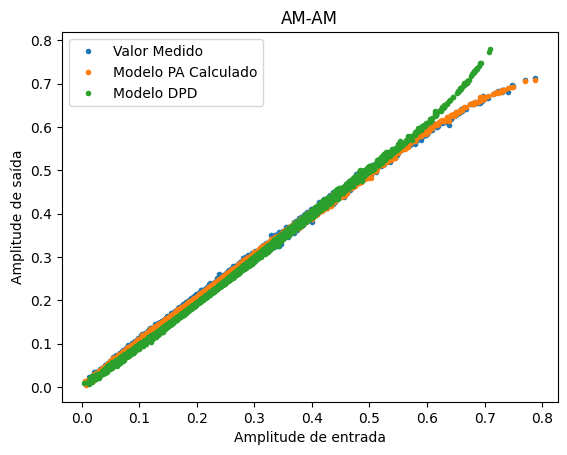

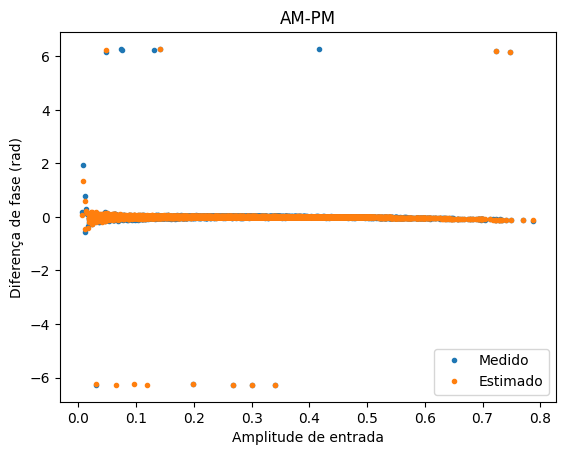

In [5]:
# Gráficos AM-AM e AM-PM
plt.figure()
plt.plot(np.abs(in_data_val), np.abs(out_data_val), '.', label='Valor Medido')
plt.plot(np.abs(in_data_val.flatten()), np.abs(predicted_val_PA.flatten()), '.', label='Modelo PA Calculado')
plt.plot(np.abs(predicted_val_PA.flatten()), np.abs(predicted_val_DPD.flatten()), '.', label='Modelo DPD')
# plt.xlim([0, 1.5])
# plt.ylim([0, 1.5])

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.figure()
plt.plot(np.abs(in_data_val), np.angle(out_data_val).flatten() - np.angle(in_data_val).flatten(), '.', label='Medido')
plt.plot(np.abs(in_data_val), np.angle(predicted_val_PA).flatten() - np.angle(in_data_val).flatten(), '.', label='Estimado')
# plt.plot(np.abs(predicted_val_PA[M:]), np.angle(predicted_val_DPD)-np.angle(predicted_val_PA[M:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.show()

In [6]:

if "coefficients_norm_pa.npy" in os.listdir(OUTPUT_DIR):
    coefficients_norm_pa = np.load(file_in_output("coefficients_norm_pa.npy"))
else:
    coefficients_norm_pa = extract_coefficients(in_ext_norm, out_ext_norm, M, P, bounds=(-1, 1))
    np.save(file_in_output("coefficients_norm_pa.npy"), coefficients_norm_pa)

# calculo dos coeficientes do modelo do PA
predicted_ext_PA = mp_model(in_ext_norm, coefficients_norm_pa, P, M)

if "coefficients_norm_DPD.npy" in os.listdir(OUTPUT_DIR):
    coefficients_norm_DPD = np.load(file_in_output("coefficients_norm_DPD.npy"))
else:
    coefficients_norm_DPD = extract_coefficients(predicted_ext_PA, in_ext_norm, M, P, bounds=(-1, 1))
    np.save(file_in_output("coefficients_norm_DPD.npy"), coefficients_norm_DPD)


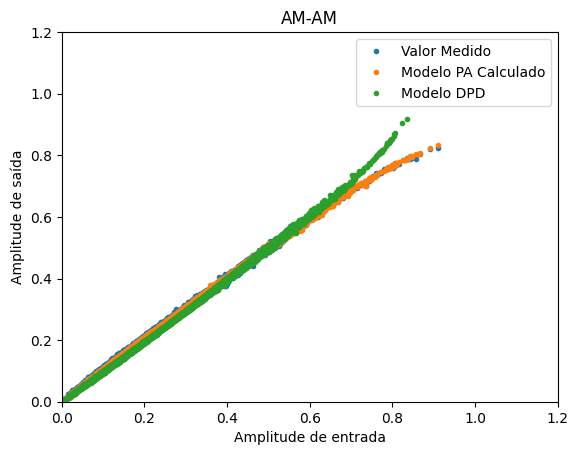

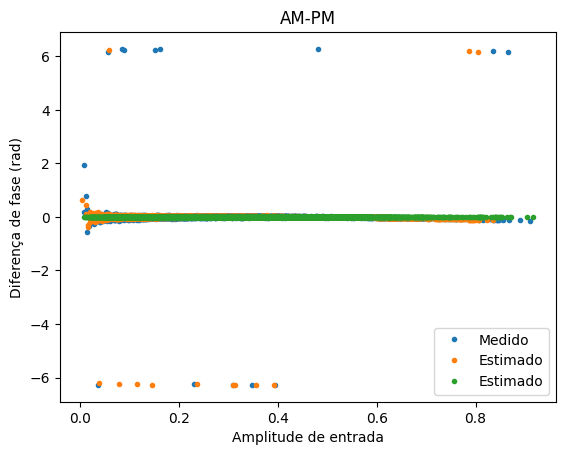

In [7]:
# saida estimada da cascata
predicted_val_PA_norm = mp_model(in_val_norm, coefficients_norm_pa, P, M)

predicted_val_DPD_norm = mp_model(predicted_val_PA_norm, coefficients_norm_DPD, P, M)

# Gráficos AM-AM e AM-PM
plt.figure()
plt.plot(np.abs(in_val_norm), np.abs(out_val_norm), '.', label='Valor Medido')
plt.plot(np.abs(in_val_norm.flatten()), np.abs(predicted_val_PA_norm.flatten()), '.', label='Modelo PA Calculado')
plt.plot(np.abs(predicted_val_PA_norm.flatten()), np.abs(predicted_val_DPD_norm.flatten()), '.', label='Modelo DPD')
plt.xlim([0, 1.2])
plt.ylim([0, 1.2])

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.figure()
plt.plot(np.abs(in_val_norm), np.angle(out_val_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Medido')
plt.plot(np.abs(predicted_val_PA_norm), np.angle(predicted_val_PA_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Estimado')
plt.plot(np.abs(predicted_val_DPD_norm), np.angle(predicted_val_DPD_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.show()

In [8]:
p_bits = 10
scale = 2 ** p_bits
# normalização
in_val_fixed = np.round(in_val_norm * scale)
out_val_fixed = np.round(out_val_norm * scale)
in_ext_fixed = np.round(in_ext_norm * scale)
out_ext_fixed = np.round(out_ext_norm * scale)


def apply_modulo_complex(value, bits):
    max_val = (2**bits) - 1

    value = np.asarray(value)

    real = np.clip(np.real(value), - max_val, max_val)
    imag = np.clip(np.imag(value), - max_val, max_val)

    return real + 1j * imag


def readeq_int(val, p_bits):
    return np.trunc(val / (2 ** p_bits))

def MultiplicadorMatrizes(coefficients, XX, precision):
    coef_q = apply_modulo_complex(coefficients, precision)

    max_value = 0
    result = np.zeros((XX.shape[0], XX.shape[1]), dtype=np.complex128)

    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            A = np.real(coef_q[j])
            B = np.imag(coef_q[j])
            C = np.real(XX[i, j])
            D = np.imag(XX[i, j])

            readequated_real = readeq_int(A * C, precision) - readeq_int(B * D, precision)
            readequated_imag = readeq_int(A * D, precision) + readeq_int(B * C, precision)

            result_complex_nomr = apply_modulo_complex(complex(readequated_real, readequated_imag), precision)
            result[i, j] = result_complex_nomr

            max_value = max(
                max_value,
                abs(np.real(result_complex_nomr)),
                abs(np.imag(result_complex_nomr))
            )

    soma_filas = np.sum(result, axis=1).reshape(-1, 1)
    soma_filas = apply_modulo_complex(soma_filas, precision)

    max_sum = max(
        np.max(np.abs(np.real(soma_filas))),
        np.max(np.abs(np.imag(soma_filas)))
    )

    max_value = max(max_value, max_sum)
    extra_bits = np.ceil(np.log2(max_value + 1)) if max_value > 0 else 0

    return soma_filas, extra_bits


def mp_int(P, M, xn, bits):
    L = xn.shape
    xn = xn.flatten()

    XX = np.zeros((L[0] - M, P * (M+1)), dtype=np.complex128)

    for l in range(M, L[0]):
        for m in range(0, M+1):
            A = np.real(xn[l - m])
            B = np.imag(xn[l - m])

            tmp_in = apply_modulo_complex(complex(A, B), bits)
            A = np.real(tmp_in)
            B = np.imag(tmp_in)

            modulo_square = readeq_int(A**2, bits) + readeq_int(B**2, bits)

            real_base = A
            imag_base = B

            for p in range(1, P+1):
                if p == 1:
                    real_part = real_base
                    imag_part = imag_base
                else:
                    real_base = readeq_int(real_base * modulo_square, bits)
                    imag_base = readeq_int(imag_base * modulo_square, bits)

                    tmp_base = apply_modulo_complex(complex(real_base, imag_base), bits)
                    real_base = np.real(tmp_base)
                    imag_base = np.imag(tmp_base)

                    real_part = real_base
                    imag_part = imag_base

                tmp = apply_modulo_complex(complex(real_part, imag_part), bits)

                col = m * P + (p - 1)
                XX[l - M, col] = tmp

    return XX



In [9]:
# modelo do PA
XX_val_PA = mp_int(P, M, in_val_fixed, p_bits)
coefficients_PA_int = np.round(coefficients_norm_pa * scale) 
predicted_val_fixed_PA, e_bits = MultiplicadorMatrizes(coefficients_PA_int, XX_val_PA, p_bits)

# modelo do DPD
XX_val_DPD = mp_int(P, M, in_val_fixed, p_bits)
coefficients_DPD_int = np.round(coefficients_norm_DPD * scale) 
predicted_val_fixed_DPD, e_bits = MultiplicadorMatrizes(coefficients_DPD_int, XX_val_DPD, p_bits)

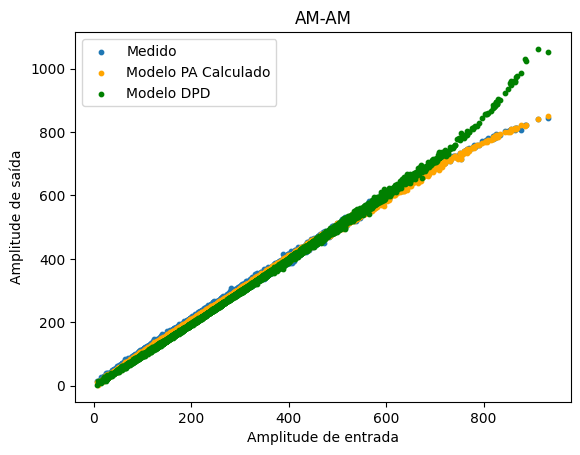

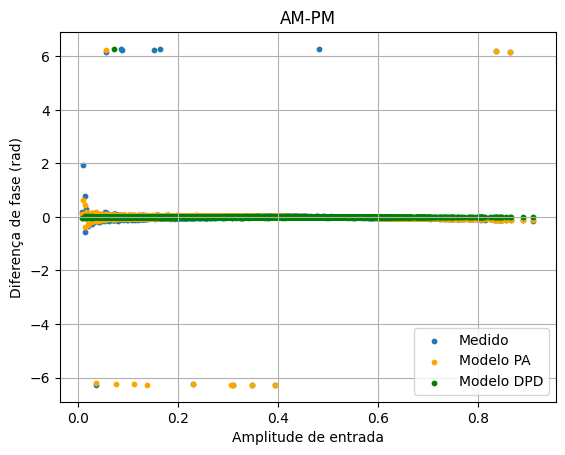

In [10]:
import pandas as pd

df_data_fixed = pd.DataFrame({
    'in_val_fixed': in_val_fixed[M:].flatten(),
    'predicted_val_fixed_PA': predicted_val_fixed_PA.flatten(),
    'predicted_val_fixed_DPD': predicted_val_fixed_DPD.flatten(),
    'out_val_fixed': out_val_fixed[M:].flatten()
})

df_amam = pd.DataFrame({
    'x_pa': np.abs(in_val_fixed[M:]).flatten(),
    'y_medido': np.abs(out_val_fixed[M:]).flatten(),
    'y_pa': np.abs(predicted_val_fixed_PA).flatten(),
    'y_dpd': np.abs(predicted_val_fixed_DPD).flatten(),
})


df_ampm = pd.DataFrame({
    'x': np.abs(in_val_norm[M:]).flatten(),
    'medido': np.angle(out_val_norm[M:]).flatten() - np.angle(in_val_norm[M:]).flatten(),
    'pa': np.angle(predicted_val_PA_norm[M:]).flatten() - np.angle(in_val_norm[M:]).flatten(),
    'dpd': np.angle(predicted_val_DPD[M:]).flatten() - np.angle(in_val_norm[M:]).flatten(),
})

ax = df_amam.plot.scatter(x='x_pa', y='y_medido', label='Medido', s=10)
df_amam.plot.scatter(x='x_pa', y='y_pa', label='Modelo PA Calculado', s=10, ax=ax, color='orange')
df_amam.plot.scatter(x='x_pa', y='y_dpd', label='Modelo DPD', s=10, ax=ax, color='green')

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')

ax = df_ampm.plot.scatter(
    x='x',
    y='medido',
    label='Medido',
    s=10,
)

df_ampm.plot.scatter(
    x='x',
    y='pa',
    label='Modelo PA',
    s=10,
    color='orange',
    ax=ax
)

df_ampm.plot.scatter(
    x='x',
    y='dpd',
    label='Modelo DPD',
    s=10,
    color='green',
    ax=ax
)

plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
init_msg = '''
onerror {resume}
quietly WaveActivateNextPane {} 0
add wave -noupdate /dpd/reset
add wave -noupdate /dpd/clk
add wave -noupdate /dpd/UR
add wave -noupdate /dpd/UI
add wave -noupdate /dpd/UR_out
add wave -noupdate /dpd/UI_out
add wave -noupdate /dpd/U_signal_out
add wave -noupdate /dpd/U_signal_in
add wave -noupdate /dpd/power_matrix
add wave -noupdate /dpd/confusion_matrix
add wave -noupdate /dpd/multiplic
add wave -noupdate /dpd/sum
TreeUpdate [SetDefaultTree]
WaveRestoreCursors {{Cursor 1} {0 ps} 0}
quietly wave cursor active 0
configure wave -namecolwidth 150
configure wave -valuecolwidth 100
configure wave -justifyvalue left
configure wave -signalnamewidth 0
configure wave -snapdistance 10
configure wave -datasetprefix 0
configure wave -rowmargin 4
configure wave -childrowmargin 2
configure wave -gridoffset 0
configure wave -gridperiod 1
configure wave -griddelta 40
configure wave -timeline 0
configure wave -timelineunits ps
update
WaveRestoreZoom {0 ps} {1 ns}

force -freeze sim:/dpd/reset 1 0
force -freeze sim:/dpd/UR 000000000 0
force -freeze sim:/dpd/UI 000000000 0
force -freeze sim:/dpd/clk 1 0, 0 {50 ps} -r 100
run 200 ps
force -freeze sim:/dpd/reset 0 0
run 100 ps
'''

data_value = '''
run 100 ps
force -freeze sim:/dpd/UR {val_rel} 0
force -freeze sim:/dpd/UI {val_imag} 0'''

inteiro_para_binario = lambda x, p_bits: format(x if x >= 0 else (1 << p_bits + 1) + x, f'0{p_bits + 1}b')

inv_val = in_val_fixed

message = init_msg
for value in inv_val[:50].flatten():
    message += data_value.format(
        val_rel  = inteiro_para_binario(int(np.real(value)), p_bits),
        val_imag = inteiro_para_binario(int(np.imag(value)), p_bits)
    )
    
with open('../VHDL/macro.do', 'w') as file_do:
    file_do.write(message)


In [12]:
import numpy as np
import os

output_file = file_in_VHDL("complex_constants.vhd")

# =========================
# CONFIG
# =========================
n_signals_used    = M + 1


complex_numbers = coefficients_DPD_int

# reshape correto
coef_matrix = complex_numbers.reshape(n_signals_used, P)

# =========================
# HEADER
# =========================
vhdl_header = f"""\
    CONSTANT n_signals_used    : INTEGER := {M} + 1;
    CONSTANT max_poly_degree   : INTEGER := {P};
    CONSTANT n_bits_resolution : INTEGER := {p_bits} + 1;
    CONSTANT n_bits_overflow   : INTEGER := {p_bits};
    
"""

# =========================
# CONVERSÃO
# =========================
def complex_to_vhdl(c):
    r = int(np.round(np.real(c))) - 1
    i = int(np.round(np.imag(c))) - 1

    return f"(reall => {r}, imag => {i})"

# =========================
# MATRIZ
# =========================
rows = []
for i in range(n_signals_used):
    row_elements = ", ".join([
        complex_to_vhdl(coef_matrix[i, j])
        for j in range(P)
    ])
    comma = "," if i < n_signals_used - 1 else ""
    rows.append(f"        ({row_elements}){comma}")

# =========================
# FOOTER
# =========================
vhdl_footer = """\
    );

END PACKAGE;
"""

# =========================
# WRITE FILE
# =========================
vhdl_content = vhdl_header
vhdl_content += "\n".join(rows)
vhdl_content += "\n" + vhdl_footer

with open(output_file, "w") as f:
    f.write(vhdl_content)

print(f"Arquivo '{output_file}' gerado com sucesso!")

Arquivo '../VHDL/complex_constants.vhd' gerado com sucesso!


In [13]:
init_msg = '''--------------------------------------------------------------------------------
LIBRARY ieee;
USE ieee.std_logic_1164.ALL;
USE IEEE.NUMERIC_STD.ALL;
USE ieee.std_logic_textio.ALL;
LIBRARY std;
USE std.env.all;
USE std.textio.ALL;
LIBRARY work;
USE work.functions.ALL;

ENTITY tb IS
END tb;
 
ARCHITECTURE behavior OF tb IS 
    -- Component Declaration for the Unit Under Test (UUT)
    COMPONENT dpd
        PORT (
            reset : IN STD_LOGIC;
            clk : IN STD_LOGIC;
            UR : IN STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UI : IN STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UR_out : OUT STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UI_out : OUT STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0)
        );
    END COMPONENT;

    -- Signals for connecting to UUT
    SIGNAL reset : STD_LOGIC := '0';
    SIGNAL clk : STD_LOGIC := '0';
    SIGNAL UR : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UI : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UR_out : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UI_out : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);

    -- Clock period definition
    CONSTANT clk_period : TIME := 16 ns;
    FILE output_file : TEXT OPEN WRITE_MODE IS "simulation_output.txt";
 
BEGIN
 
	-- Instantiate the Unit Under Test (UUT)
   uut: DPD PORT MAP (
          reset => reset,
          clk => clk,
          UR => UR,
          UI => UI,
          UR_out => UR_out,
          UI_out => UI_out
        );

   -- Clock process definitions
   clk_process :process
   begin
		clk <= '0';
		wait for clk_period/2;
		clk <= '1';
		wait for clk_period/2;
   end process;
 
    write_output : PROCESS(clk)
        VARIABLE line_buffer : LINE;
        VARIABLE data : INTEGER;
    BEGIN
        IF reset = '0' and rising_edge(clk) THEN
            WRITE(line_buffer, to_integer(signed(UR_out)));
            WRITE(line_buffer, STRING'(","));
            WRITE(line_buffer, to_integer(signed(UI_out)));
            WRITE(line_buffer, STRING'("j"));
            WRITELINE(output_file, line_buffer);
        END IF;
    END PROCESS;

      -- in process
   calc_proc: process
   begin		
      reset <= '1';
      wait for 2 * clk_period;	
      reset <= '0';
      WAIT FOR clk_period;
      {values}

      report "Fim da simulacao" severity note;
      finish;
   end process;
   
END;
'''

data_value = '''
    UR <= "{val_rel}";
    UI <= "{val_imag}";
    WAIT FOR clk_period;
'''

inteiro_para_binario = lambda x, p_bits: format(x if x >= 0 else (1 << (p_bits + 1)) + x, f'0{p_bits + 1}b')

inv_val = in_val_fixed

message = ''
for value in inv_val.flatten():
    message += data_value.format(
        val_rel  = inteiro_para_binario(int(np.real(value)), p_bits),
        val_imag = inteiro_para_binario(int(np.imag(value)), p_bits)
    )
tb_file = file_in_VHDL("tb_main.vhd")

# Escrevendo o conteúdo no arquivo
with open(tb_file, "w") as f:
    f.write(init_msg.format(values = message))

print(f"Arquivo VHDL '{tb_file}' gerado com sucesso!")


Arquivo VHDL '../VHDL/tb_main.vhd' gerado com sucesso!


In [23]:
import pandas as pd
import numpy as np
import os

out_signal = pd.read_csv(os.path.join(OUTPUT_DIR, 'simulation_output-gabs.txt'))
out_signal = out_signal.astype(complex)

out_sintesi = (out_signal['0'] + out_signal['0j']).values.flatten()
pred = predicted_val_fixed_DPD.flatten()

def estimate_delay(sim, ref, max_delay=50):
    best_delay = 0
    best_score = -np.inf

    for d in range(max_delay + 1):
        sim_d = sim[d:]
        ref_d = ref[:len(sim_d)]

        if len(sim_d) == 0 or len(ref_d) == 0:
            continue

        n = min(len(sim_d), len(ref_d))
        sim_n = sim_d[:n]
        ref_n = ref_d[:n]

        score = np.abs(np.vdot(sim_n, ref_n))

        if score > best_score:
            best_score = score
            best_delay = d

    return best_delay

delay = estimate_delay(out_sintesi, pred, max_delay=20)
print(f"Atraso estimado: {delay} amostras")

out_sintesi = out_sintesi[delay:]

n = min(len(out_sintesi), len(pred))
out_sintesi = out_sintesi[:n]
pred = pred[:n]

np.save("vetor_simulado.npy", out_sintesi)
np.save("vetor_calculado.npy", pred)

Atraso estimado: 6 amostras


/tmp/ipykernel_4429/74226085.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


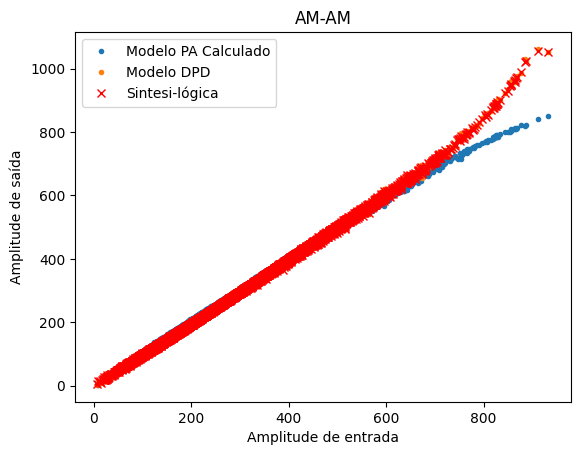

In [24]:
nmse_calculo_sim = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

predicted_val_fixed_pre = predicted_val_fixed_DPD.reshape(-1, 1)
# in_val_fixed = np.array(in_val_fixed)

# out_sintesi = out_sintesi[100:]
nmse_sintese = nmse_calculo_sim(predicted_val_fixed_pre[:out_sintesi.shape[0]], out_sintesi)
fig, ax = plt.subplots()
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_PA), '.', label='Modelo PA Calculado')
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_DPD), '.', label='Modelo DPD')
ax.plot(np.abs(in_val_fixed[M:M + len(out_sintesi)]), np.abs(out_sintesi), 'x', label='Sintesi-lógica', color='red')
# ax.set_xlim([0, 2 ** p_bits])
# ax.set_ylim([0, 2 ** p_bits])

ax.set_xlabel('Amplitude de entrada')
ax.set_ylabel('Amplitude de saída')
ax.set_title('AM-AM')
ax.legend()
fig.show()

# Coeficientes truncados

In [16]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model_ordem_variavel(x_in, coef, ordens):
    """
    ordens : lista ou array com P_m para cada atraso
             tamanho = memoria + 1
    """
    x_in = x_in.flatten()
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex)

    idx = 0
    memoria = len(ordens) - 1

    for m in range(memoria + 1):
        x_delay = np.roll(x_in, m)

        Pm = ordens[m]
        coef_m = coef[idx:idx + Pm]
        idx += Pm

        y_est += bloco_memoria_mp(x_delay, coef_m, Pm)

    return y_est


def erro_mp_complex_ordem_variavel(params, x_in, y_out, ordens):
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model_ordem_variavel(x_in, coef, ordens)
    erro = y_out - y_est

    return np.abs(erro)


def extract_coefficients_ordem_variavel(in_ext, out_ext, ordens, bounds=(-np.inf, np.inf)):
    in_ext = in_ext.flatten()
    out_ext = out_ext.flatten()
    num_coef = sum(ordens)
    x0 = np.zeros(2 * num_coef)

    res = least_squares(
        erro_mp_complex_ordem_variavel,
        x0,
        bounds=bounds,
        args=(in_ext, out_ext, ordens),
        verbose=2
    )

    coefficients = res.x[:num_coef] + 1j * res.x[num_coef:]
    print("Coeficientes complexos otimizados:", coefficients)

    return coefficients


# modelo do PA

def mp_int_trunc(xn, bits, ordens):
    xn = xn.flatten()

    M = len(ordens) - 1
    total_cols = sum(ordens)

    XX = np.zeros((len(xn) - M, total_cols), dtype=np.complex128)

    for l in range(M, len(xn)):
        col_idx = 0

        for m in range(0, M + 1):
            A = np.real(xn[l - m])
            B = np.imag(xn[l - m])

            tmp_in = apply_modulo_complex(complex(A, B), bits)
            A = int(np.real(tmp_in))
            B = int(np.imag(tmp_in))

            modulo_square = int(readeq_int(A**2, bits) + readeq_int(B**2, bits))

            real_base = A
            imag_base = B

            Pm = ordens[m]

            for p in range(1, Pm + 1):
                if p == 1:
                    real_part = real_base
                    imag_part = imag_base
                else:
                    real_base = readeq_int(real_base * modulo_square, bits)
                    imag_base = readeq_int(imag_base * modulo_square, bits)

                    tmp_base = apply_modulo_complex(complex(real_base, imag_base), bits)
                    real_base = int(np.real(tmp_base))
                    imag_base = int(np.imag(tmp_base))

                    real_part = real_base
                    imag_part = imag_base

                XX[l - M, col_idx] = apply_modulo_complex(complex(real_part, imag_part), bits)
                col_idx += 1

    return XX
  


In [17]:
ordens = [5,3,1]
num_coef = sum(ordens)


if "coefficients_norm_pa_trunc.npy" in os.listdir(OUTPUT_DIR):
    coefficients_norm_pa_trunc = np.load(file_in_output("coefficients_norm_pa_trunc.npy"))
else:
    coefficients_norm_pa_trunc = extract_coefficients_ordem_variavel(in_ext_norm, out_ext_norm, ordens, bounds=(-1, 1))
    np.save(file_in_output("coefficients_norm_pa_trunc.npy"), coefficients_norm_pa_trunc)

# calculo dos coeficientes do modelo do PA
predicted_ext_PA_trunc = mp_model_ordem_variavel(in_ext_norm.flatten(), coefficients_norm_pa_trunc, ordens)

if "coefficients_norm_DPD_trunc.npy" in os.listdir(OUTPUT_DIR):
    coefficients_norm_DPD_trunc = np.load(file_in_output("coefficients_norm_DPD_trunc.npy"))
else:
    coefficients_norm_DPD_trunc = extract_coefficients_ordem_variavel(predicted_ext_PA_trunc, in_ext_norm, ordens, bounds=(-1, 1))
    np.save(file_in_output("coefficients_norm_DPD_trunc.npy"), coefficients_norm_DPD_trunc)

XX_val_PA_trunc = mp_int_trunc(in_val_fixed, p_bits, ordens)
coefficients_PA_int = np.round(coefficients_norm_pa_trunc * scale) 
predicted_val_fixed_PA_trunc, e_bits = MultiplicadorMatrizes(coefficients_PA_int, XX_val_PA_trunc, p_bits)

# modelo do DPD
XX_val_DPD_trunc = mp_int_trunc(in_val_fixed, p_bits, ordens)
coefficients_DPD_int_trunc = np.round(coefficients_norm_DPD_trunc * scale) 
predicted_val_fixed_DPD_trunc, e_bits = MultiplicadorMatrizes(coefficients_DPD_int_trunc, XX_val_DPD_trunc, p_bits)

In [18]:
coefficients_DPD_int_trunc

array([1022. -21.j,  591. -18.j, -849.+139.j,  157.+117.j,  737.+289.j,
       -123. +15.j, -318.  +9.j,  268.  +1.j,   93.  -3.j])

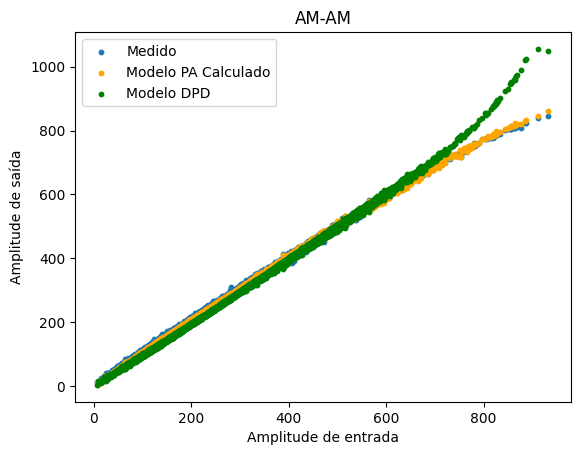

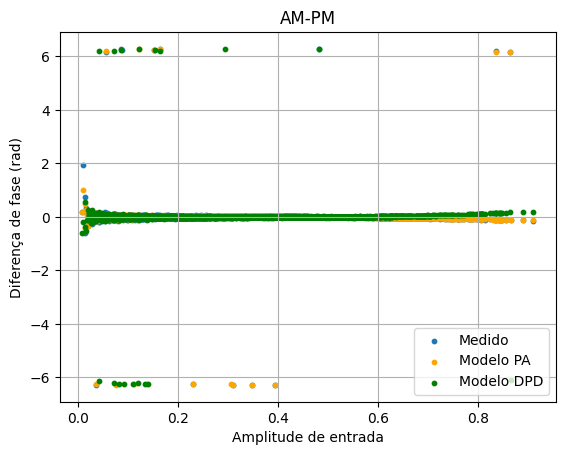

In [19]:
import pandas as pd

df_data_fixed = pd.DataFrame({
    'in_val_fixed': in_val_fixed[M:].flatten(),
    'predicted_val_fixed_PA': predicted_val_fixed_PA_trunc.flatten(),
    'predicted_val_fixed_DPD': predicted_val_fixed_DPD_trunc.flatten(),
    'out_val_fixed': out_val_fixed[M:].flatten()
})

df_amam = pd.DataFrame({
    'x_pa': np.abs(in_val_fixed[M:]).flatten(),
    'y_medido': np.abs(out_val_fixed[M:]).flatten(),
    'y_pa': np.abs(predicted_val_fixed_PA_trunc).flatten(),
    'y_dpd': np.abs(predicted_val_fixed_DPD_trunc).flatten(),
})


df_ampm = pd.DataFrame({
    'x': np.abs(in_val_norm[M:]).flatten(),
    'medido': np.angle(out_val_norm[M:]).flatten() - np.angle(in_val_fixed[M:]).flatten(),
    'pa': np.angle(predicted_val_fixed_PA_trunc).flatten() - np.angle(in_val_fixed[M:]).flatten(),
    'dpd': np.angle(predicted_val_fixed_DPD_trunc).flatten() - np.angle(in_val_fixed[M:]).flatten(),
})

ax = df_amam.plot.scatter(x='x_pa', y='y_medido', label='Medido', s=10)
df_amam.plot.scatter(x='x_pa', y='y_pa', label='Modelo PA Calculado', s=10, ax=ax, color='orange')
df_amam.plot.scatter(x='x_pa', y='y_dpd', label='Modelo DPD', s=10, ax=ax, color='green')

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')

ax = df_ampm.plot.scatter(
    x='x',
    y='medido',
    label='Medido',
    s=10,
)

df_ampm.plot.scatter(
    x='x',
    y='pa',
    label='Modelo PA',
    s=10,
    color='orange',
    ax=ax
)

df_ampm.plot.scatter(
    x='x',
    y='dpd',
    label='Modelo DPD',
    s=10,
    color='green',
    ax=ax
)

plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
output_file = file_in_VHDL("complex_constants.vhd")

complex_numbers = coefficients_norm_DPD_trunc * (2 ** p_bits)
ordens = [5, 3, 1]

n_signals_used = len(ordens)
max_polygnos_degree = max(ordens)

# matriz preenchida com zero
coef_matrix = np.zeros((n_signals_used, max_polygnos_degree), dtype=np.complex128)

idx = 0
for m, Pm in enumerate(ordens):
    coef_matrix[m, :Pm] = complex_numbers[idx:idx + Pm]
    idx += Pm

def to_vhdl_int(x):
    return int(np.trunc(np.real(x)))


vhdl_header = f"""\
  CONSTANT n_signals_used : INTEGER := {n_signals_used};
  CONSTANT max_poly_degree : INTEGER := {max_polygnos_degree};
  CONSTANT n_bits_resolution : INTEGER := {p_bits} + 1; -- +1 para o bit de sinal
  CONSTANT n_bits_overflow   : INTEGER := {int(e_bits)};

  TYPE degree_array_t IS ARRAY (0 TO n_signals_used - 1) OF INTEGER;
  CONSTANT poly_degree_per_delay : degree_array_t := (5, 3, 1);

  TYPE complex_type IS RECORD
    reall : INTEGER;
    imag  : INTEGER;
  END RECORD;

  TYPE complex_array IS ARRAY (0 TO n_signals_used - 1, 0 TO n_polygnos_degree - 1) OF complex_type;

  CONSTANT coefficients : complex_array := (
"""


rows = []
for m in range(n_signals_used):
    cols = []
    for p in range(max_polygnos_degree):
        real_part = int(np.trunc(np.real(coef_matrix[m, p])))
        imag_part = int(np.trunc(np.imag(coef_matrix[m, p])))
        cols.append(f"(reall => {real_part}, imag => {imag_part})")
    rows.append("    (" + ", ".join(cols) + ")")

vhdl_body = ",\n".join(rows)
vhdl_footer = "\n  );\n"


with open(output_file, "w") as f:
    f.write(vhdl_header)
    f.write(vhdl_body)
    f.write(vhdl_footer)

In [21]:
import pandas as pd
import numpy as np
import os

out_signal = pd.read_csv(os.path.join(OUTPUT_DIR, 'simulation_output.txt'))
out_signal = out_signal.astype(complex)

out_sintesi = (out_signal['0'] + out_signal['0j']).values.flatten()
pred = predicted_val_fixed_DPD_trunc.flatten()

import numpy as np

def estimate_delay_mae(sim, ref, max_delay=50, discard_head=0):
    sim = np.asarray(sim).flatten()[discard_head:]
    ref = np.asarray(ref).flatten()[discard_head:]

    best_delay = 0
    best_err = np.inf

    for d in range(max_delay + 1):
        sim_d = sim[d:]
        ref_d = ref[:len(sim_d)]

        n = min(len(sim_d), len(ref_d))
        if n <= 0:
            continue

        sim_n = sim_d[:n]
        ref_n = ref_d[:n]

        err = np.mean(np.abs(sim_n - ref_n))

        if err < best_err:
            best_err = err
            best_delay = d

    return best_delay, best_err


delay, err = estimate_delay_mae(out_sintesi, pred, max_delay=15, discard_head=10)
print("delay =", delay, "mae =", err)
out_sintesi = out_sintesi[delay:]

n = min(len(out_sintesi), len(pred))
out_sintesi = out_sintesi[:n]
pred = pred[:n]

np.save("vetor_simulado_trunc.npy", out_sintesi)
np.save("vetor_calculado_trunc.npy", pred)

delay = 13 mae = 0.00044672771945499217


/tmp/ipykernel_4429/1815325438.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


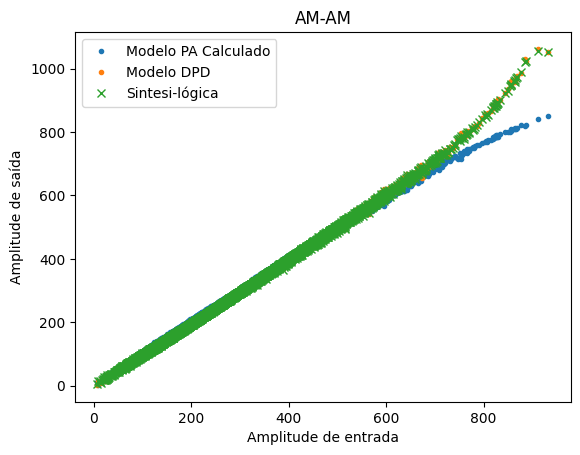

In [22]:
nmse_calculo_sim = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

predicted_val_fixed_pre = predicted_val_fixed_DPD.reshape(-1, 1)
# in_val_fixed = np.array(in_val_fixed)

# out_sintesi = out_sintesi[100:]
nmse_sintese = nmse_calculo_sim(predicted_val_fixed_pre[:out_sintesi.shape[0]], out_sintesi)
fig, ax = plt.subplots()
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_PA), '.', label='Modelo PA Calculado')
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_DPD), '.', label='Modelo DPD')
ax.plot(np.abs(in_val_fixed[M:M + len(out_sintesi)]), np.abs(out_sintesi), 'x', label='Sintesi-lógica')
# ax.set_xlim([0, 2 ** p_bits])
# ax.set_ylim([0, 2 ** p_bits])

ax.set_xlabel('Amplitude de entrada')
ax.set_ylabel('Amplitude de saída')
ax.set_title('AM-AM')
ax.legend()
fig.show()